<a href="https://colab.research.google.com/github/VikramHub27/UM-Intern/blob/main/Daily_Transactions_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                  Date                   Mode        Category  \
0  20/09/2018 12:04:08                   Cash  Transportation   
1  20/09/2018 12:03:15                   Cash            Food   
2           19/09/2018  Saving Bank account 1    subscription   
3  17/09/2018 23:41:17  Saving Bank account 1    subscription   
4  16/09/2018 17:15:08                   Cash       Festivals   

               Subcategory                         Note  Amount  \
0                    Train         2 Place 5 to Place 0    30.0   
1                   snacks  Idli medu Vada mix 2 plates    60.0   
2                  Netflix         1 month subscription   199.0   
3  Mobile Service Provider            Data booster pack    19.0   
4             Ganesh Pujan                  Ganesh idol   251.0   

  Income/Expense Currency  
0        Expense      INR  
1        Expense      INR  
2        Expense      INR  
3        Expense      INR  
4        Expense      INR  
Date                0
Mode            

<ipython-input-5-0dc0042deeb4>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna('Unknown', inplace=True)
<ipython-input-5-0dc0042deeb4>:20: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Added error handling


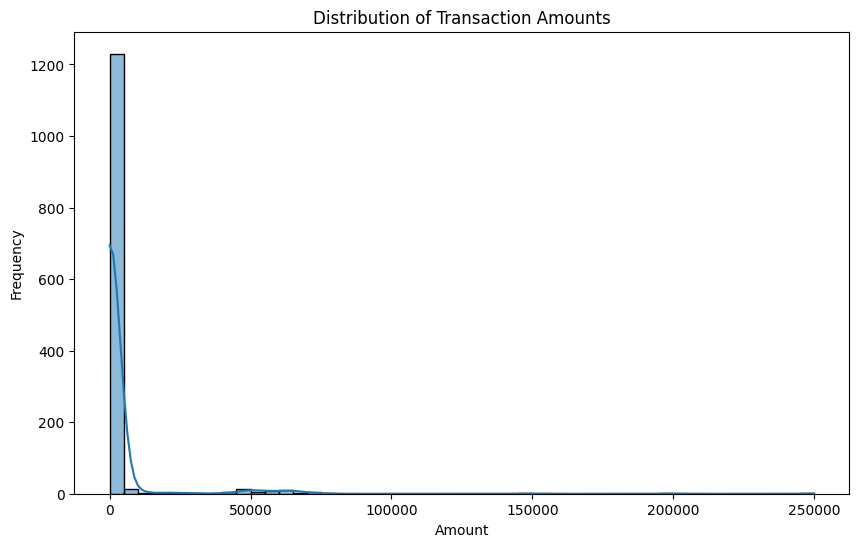

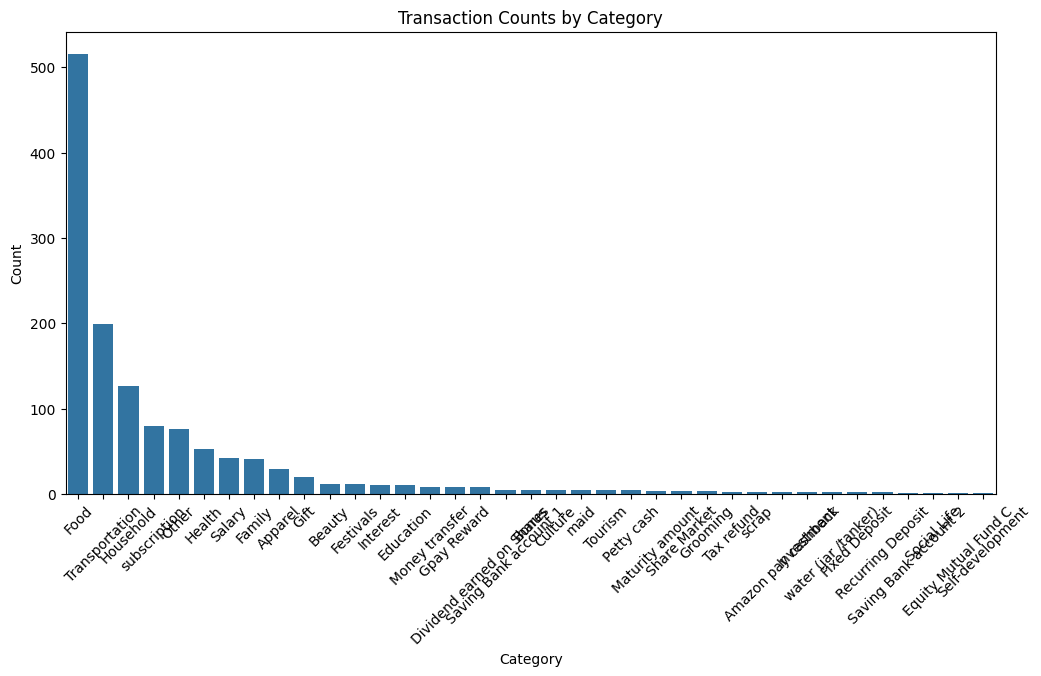

<ipython-input-5-0dc0042deeb4>:63: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.set_index('Date').resample('M')['Amount'].sum()


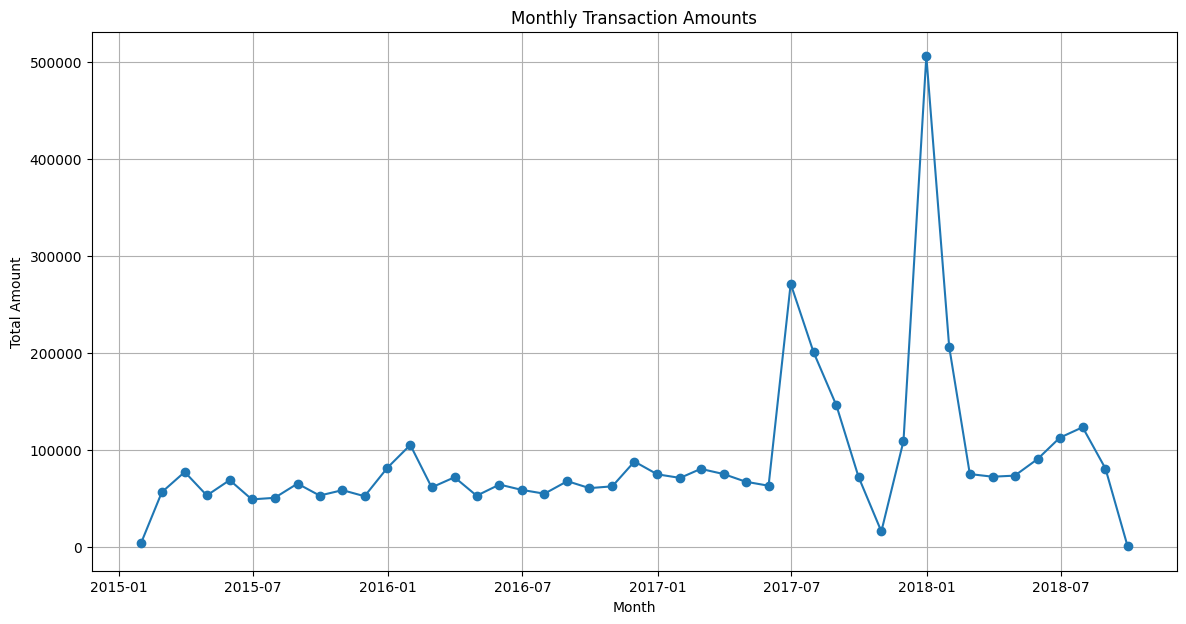

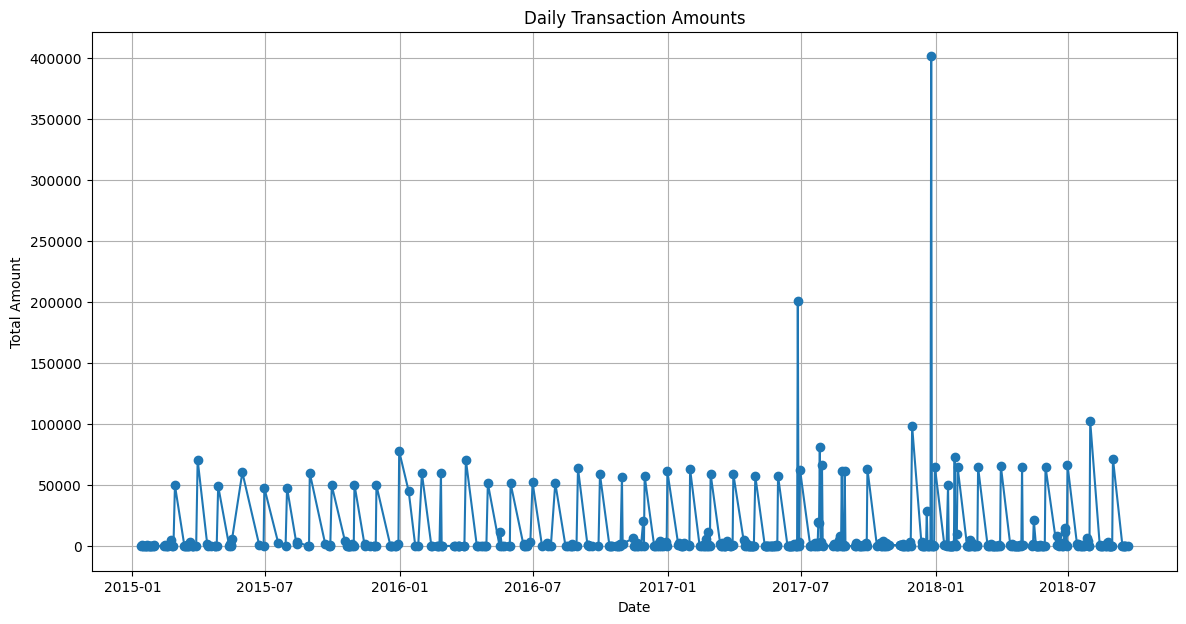

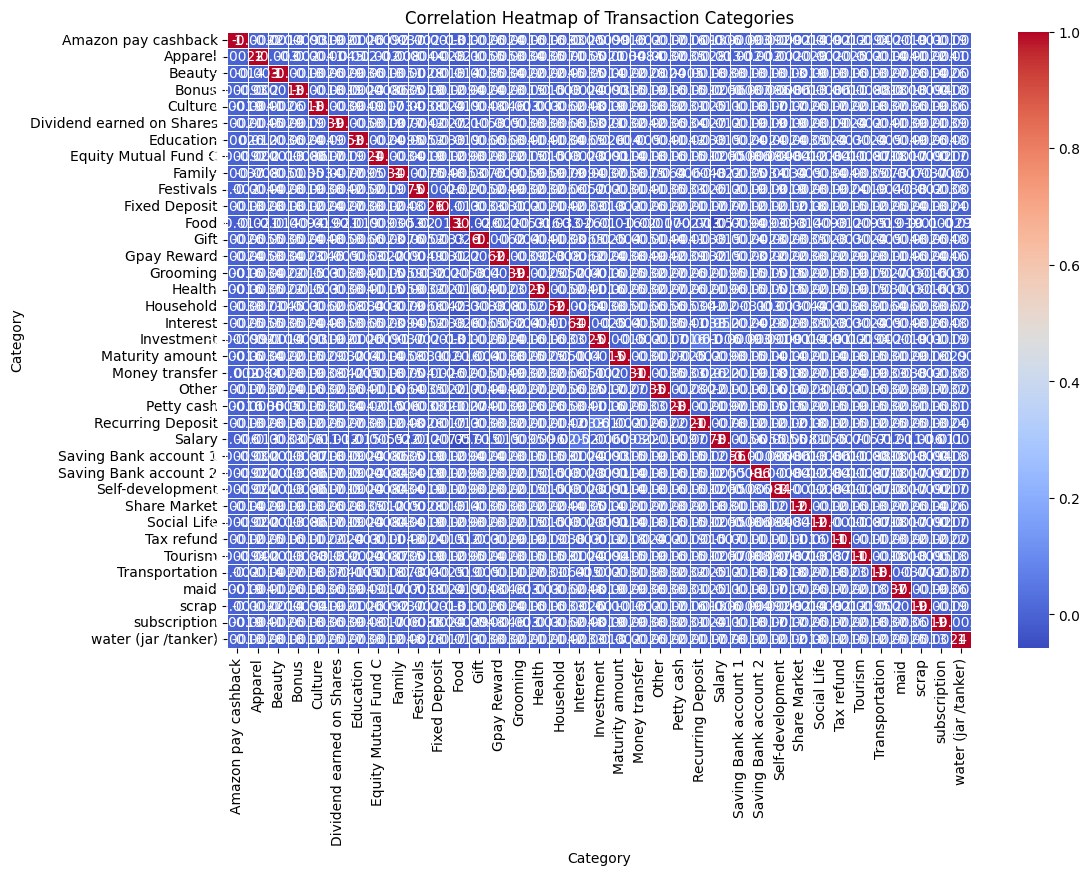

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/daily_transactions.csv')

# Display the first few rows of the dataset
print(df.head())  # Needs print to actually display when run as script

# Check for missing values
print(df.isnull().sum())  # Needs print to show output

# Fill or drop missing values
if 'Category' in df.columns:
    df['Category'].fillna('Unknown', inplace=True)

# Convert data types
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Added error handling
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')  # In case of bad data

# Drop any rows with NaN after type conversion
df.dropna(subset=['Date', 'Amount'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify data types
print(df.dtypes)

# Summary statistics
print(df.describe())

# Distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Transaction counts by category
if 'Category' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
    plt.title('Transaction Counts by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# Transaction counts by type
if 'Type' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Type')
    plt.title('Transaction Counts by Type')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.show()

# Resample data to monthly frequency
monthly_data = df.set_index('Date').resample('M')['Amount'].sum()
plt.figure(figsize=(14, 7))
plt.plot(monthly_data.index, monthly_data.values, marker='o')
plt.title('Monthly Transaction Amounts')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

# Daily trends
daily_data = df.groupby(df['Date'].dt.date)['Amount'].sum()
plt.figure(figsize=(14, 7))
plt.plot(daily_data.index, daily_data.values, marker='o')
plt.title('Daily Transaction Amounts')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

# Create a pivot table for correlation analysis
if 'Category' in df.columns:
    pivot_table = df.pivot_table(index='Date', columns='Category', values='Amount',
                                 aggfunc='sum', fill_value=0)

    # Calculate correlation matrix
    correlation_matrix = pivot_table.corr()

    # Plot correlation heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap of Transaction Categories')
    plt.show()
